In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d andrewmvd/pediatric-pneumonia-chest-xray

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/pediatric-pneumonia-chest-xray
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.14G/1.14G [00:11<00:00, 108MB/s] 



In [ ]:
import os

base_path = "/content/pneumonia_data"

for root, dirs, files in os.walk(base_path):
    print(root, len(files))

In [ ]:
!unzip -q /content/pediatric-pneumonia-chest-xray.zip -d /content/pneumonia_data

In [ ]:
import os

base_path = "/content/pneumonia_data"

for root, dirs, files in os.walk(base_path):
    print(root, len(files))

/content/pneumonia_data 0
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia 0
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train 0
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train/PNEUMONIA 3883
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train/NORMAL 1349
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test 0
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA 390
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test/NORMAL 234


In [ ]:
import os

for root, dirs, files in os.walk("/content/pneumonia_data"):
    if files:
        print(root, "→", len(files), "images")

/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train/PNEUMONIA → 3883 images
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train/NORMAL → 1349 images
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA → 390 images
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test/NORMAL → 234 images


Normal images: 1349
Pneumonia images: 3883


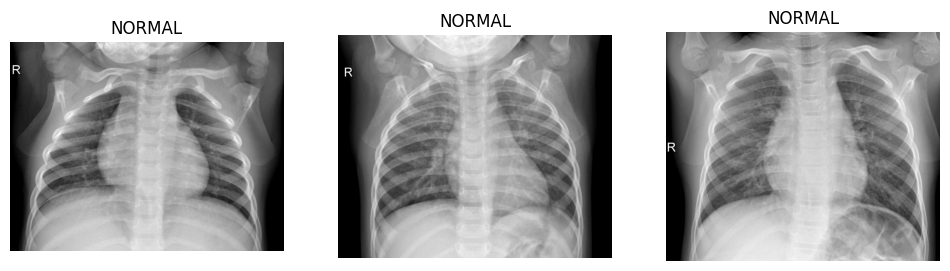

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import glob
import os

normal_images = glob.glob(
    "/content/pneumonia_data/**/train/NORMAL/*.jpeg",
    recursive=True
)

pneumonia_images = glob.glob(
    "/content/pneumonia_data/**/train/PNEUMONIA/*.jpeg",
    recursive=True
)

print("Normal images:", len(normal_images))
print("Pneumonia images:", len(pneumonia_images))

plt.figure(figsize=(12, 5))

for i, img_path in enumerate(normal_images[:3]):
    plt.subplot(1, 3, i + 1)
    img = Image.open(img_path)
    plt.imshow(img, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")

plt.show()

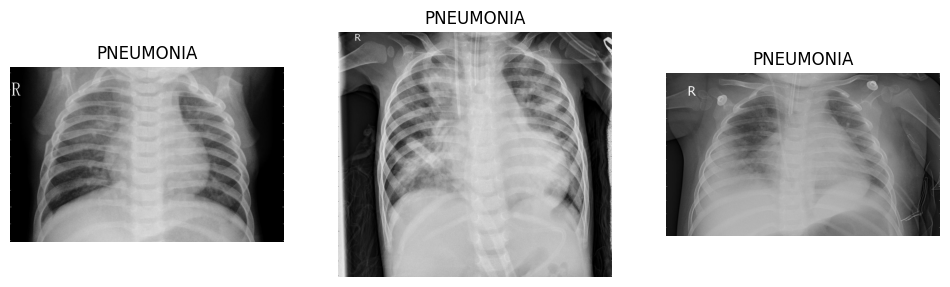

In [ ]:
plt.figure(figsize=(12, 5))

for i, img_path in enumerate(pneumonia_images[:3]):
    plt.subplot(1, 3, i + 1)
    img = Image.open(img_path)
    plt.imshow(img, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.show()

In [ ]:
import os

for root, dirs, files in os.walk("/content/pneumonia_data"):
    if files:
        print(root)

/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train/PNEUMONIA
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train/NORMAL
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test/NORMAL


In [ ]:
import os

DATASET_PATH = "/content/pneumonia_data/chest_xray"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: /content/pneumonia_data/chest_xray/train
Validation: /content/pneumonia_data/chest_xray/val
Test: /content/pneumonia_data/chest_xray/test


In [ ]:
import os

for root, dirs, files in os.walk("/content/pneumonia_data"):
    print(root)

/content/pneumonia_data
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train/PNEUMONIA
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train/NORMAL
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA
/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test/NORMAL


In [ ]:
TRAIN_DIR = "/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train"
TEST_DIR = "/content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test"

print("Train:", TRAIN_DIR)
print("Test:", TEST_DIR)

Train: /content/pneumonia_data/Pediatric Chest X-ray Pneumonia/train
Test: /content/pneumonia_data/Pediatric Chest X-ray Pneumonia/test


In [ ]:
import os

print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))

Train classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
    validation_split=0.20,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

Found 4187 images belonging to 2 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 1045 images belonging to 2 classes.


In [ ]:
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
)

In [ ]:
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [ ]:
print("Class mapping:", train_generator.class_indices)

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)

Training images: 4187
Validation images: 1045
Test images: 624


In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("VGG16 loaded successfully!")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded successfully!


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.7647 - loss: 0.7282 - val_accuracy: 0.9129 - val_loss: 0.2189
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 830ms/step - accuracy: 0.8741 - loss: 0.3354 - val_accuracy: 0.9100 - val_loss: 0.1933
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 818ms/step - accuracy: 0.8971 - loss: 0.2722 - val_accuracy: 0.9321 - val_loss: 0.1694
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 834ms/step - accuracy: 0.9135 - loss: 0.2254 - val_accuracy: 0.9416 - val_loss: 0.1492
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 823ms/step - accuracy: 0.9147 - loss: 0.2096 - val_accuracy: 0.9464 - val_loss: 0.1438
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 831ms/step - accuracy: 0.9176 - loss: 0.2042 - val_accuracy: 0.9455 - val_loss: 0.1436
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 843ms/step - accuracy: 0.9348 - loss: 0.1795 - val_accuracy: 0.9502 - val_loss: 0.1270
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 128s 981ms/step - accuracy: 0.9326 - lo

In [ ]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained VGG16 layers
base_model.trainable = False

print("VGG16 loaded successfully!")

VGG16 loaded successfully!


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 114s 851ms/step - accuracy: 0.6324 - loss: 1.6776 - val_accuracy: 0.8785 - val_loss: 0.3104
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 837ms/step - accuracy: 0.8171 - loss: 0.6016 - val_accuracy: 0.9100 - val_loss: 0.2212
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 832ms/step - accuracy: 0.8682 - loss: 0.3815 - val_accuracy: 0.9301 - val_loss: 0.1653
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 828ms/step - accuracy: 0.8877 - loss: 0.3144 - val_accuracy: 0.9349 - val_loss: 0.1476
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 143s 837ms/step - accuracy: 0.8963 - loss: 0.2548 - val_accuracy: 0.9426 - val_loss: 0.1462
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 827ms/step - accuracy: 0.9112 - loss: 0.2217 - val_accuracy: 0.9493 - val_loss: 0.1360
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 833ms/step - accuracy: 0.9128 - loss: 0.2287 - val_accuracy: 0.9541 - val_loss: 0.1302
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 823ms/step - accuracy: 0.9236 -

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 797ms/step - accuracy: 0.8494 - loss: 0.3607
Test Loss: 0.36073315143585205
Test Accuracy: 0.8493589758872986
Test Accuracy (%): 84.93589758872986


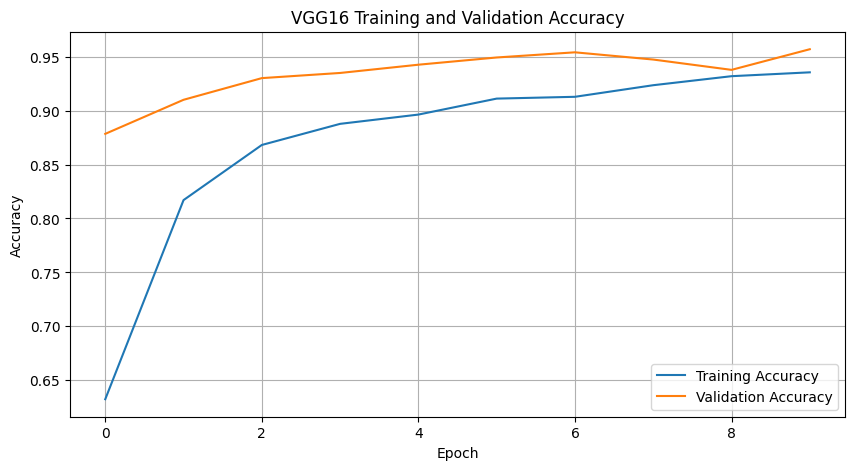

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("VGG16 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

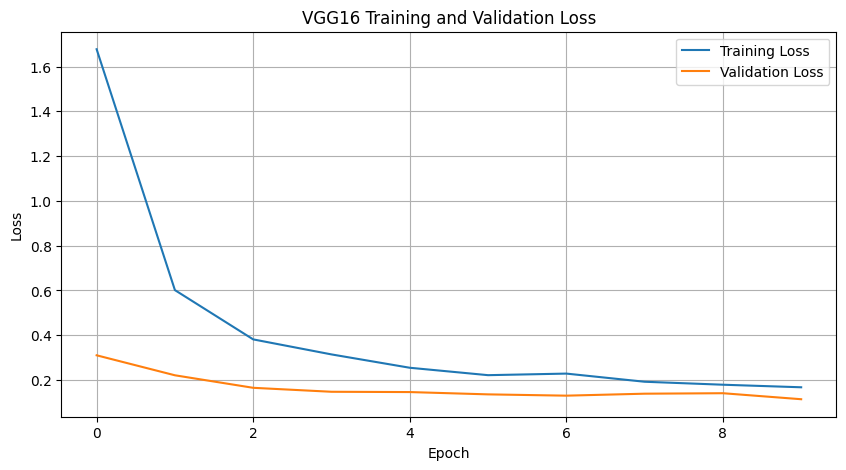

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("VGG16 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import numpy as np

test_generator.reset()

predictions = model.predict(test_generator)

predicted_classes = (predictions >= 0.5).astype(int).ravel()

true_classes = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 282ms/step


In [ ]:
print("Predictions:", predicted_classes[:20])
print("Actual:", true_classes[:20])

Predictions: [0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0]
Actual: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.94      0.64      0.76       234
   PNEUMONIA       0.82      0.97      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.81      0.83       624
weighted avg       0.86      0.85      0.84       624



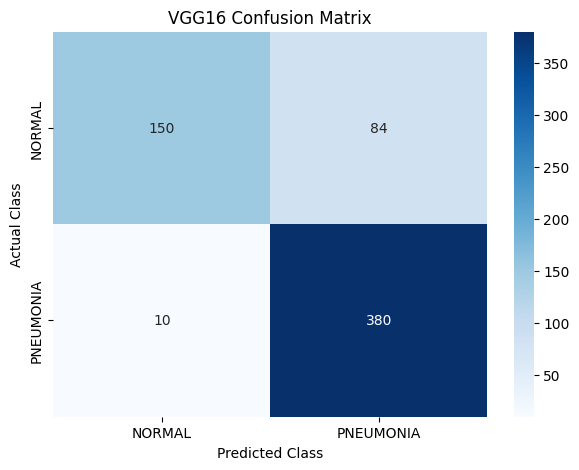

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("VGG16 Confusion Matrix")

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 380ms/step - accuracy: 0.8494 - loss: 0.3607
Test Loss: 0.36073315143585205
Test Accuracy: 0.8493589758872986
Test Accuracy (%): 84.93589758872986


In [ ]:
import numpy as np

# Reset test generator
test_generator.reset()

# Generate predictions
predictions = model.predict(test_generator)

# Convert probabilities to classes
predicted_classes = (predictions >= 0.5).astype(int).ravel()

# Actual classes
true_classes = test_generator.classes

print("Prediction completed!")
print("Total test images:", len(true_classes))

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 318ms/step
Prediction completed!
Total test images: 624


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL", "PNEUMONIA"]
)

print(report)

              precision    recall  f1-score   support

      NORMAL       0.94      0.64      0.76       234
   PNEUMONIA       0.82      0.97      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.81      0.83       624
weighted avg       0.86      0.85      0.84       624



Confusion Matrix:
[[150  84]
 [ 10 380]]


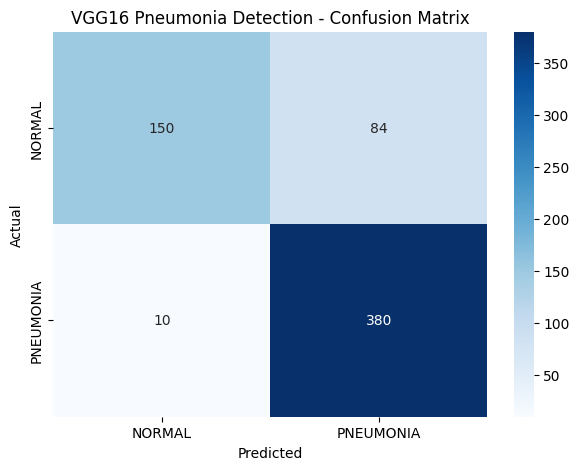

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Pneumonia Detection - Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

# Probability of PNEUMONIA
y_scores = predictions.ravel()

# Calculate ROC
fpr, tpr, thresholds = roc_curve(true_classes, y_scores)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9476550515012053


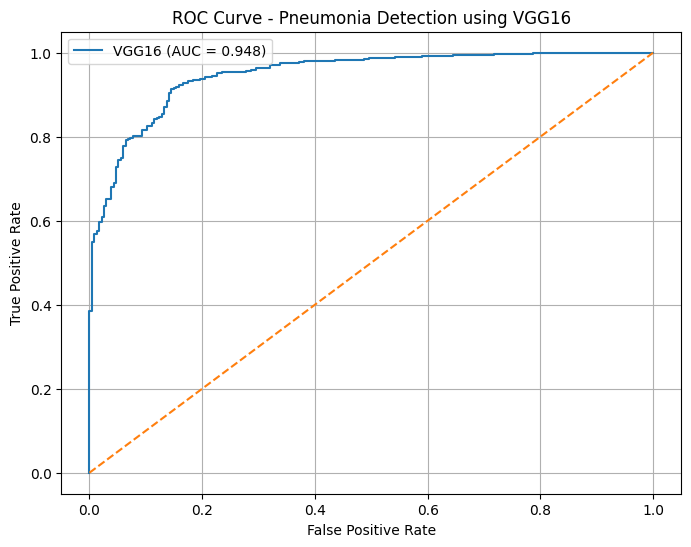

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"VGG16 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Pneumonia Detection using VGG16")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.save("/content/pneumonia_vgg16.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(
    "Model size:",
    round(os.path.getsize("/content/pneumonia_vgg16.keras") / (1024 * 1024), 2),
    "MB"
)

Model size: 56.97 MB


In [ ]:
from google.colab import files

files.download("/content/pneumonia_vgg16.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

zip_files = [
    "/content/pediatric-pneumonia-chest-xray.zip",
    "/content/Pediatric Chest X-ray Pneumonia.zip"
]

for f in zip_files:
    if os.path.exists(f):
        os.remove(f)
        print("Deleted:", f)

Deleted: /content/pediatric-pneumonia-chest-xray.zip


In [ ]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   65G  43% /


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_folder = "/content/drive/MyDrive/Pneumonia_VGG16"

os.makedirs(project_folder, exist_ok=True)

print("Project folder created!")

Project folder created!


In [ ]:
model_path = "/content/drive/MyDrive/Pneumonia_VGG16/pneumonia_vgg16.keras"

model.save(model_path)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
/content/drive/MyDrive/Pneumonia_VGG16/pneumonia_vgg16.keras


In [ ]:
import os

print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print(
        "Model size:",
        round(os.path.getsize(model_path) / (1024 * 1024), 2),
        "MB"
    )

Exists: True
Model size: 56.97 MB


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Reset test generator
test_generator.reset()

# Get prediction probabilities
predictions = model.predict(test_generator)

# Convert probabilities to classes
predicted_classes = (predictions >= 0.5).astype(int).ravel()

# Actual classes
true_classes = test_generator.classes

# Classification report
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL", "PNEUMONIA"]
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 299ms/step
              precision    recall  f1-score   support

      NORMAL       0.94      0.64      0.76       234
   PNEUMONIA       0.82      0.97      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.81      0.83       624
weighted avg       0.86      0.85      0.84       624



Confusion Matrix:
[[150  84]
 [ 10 380]]


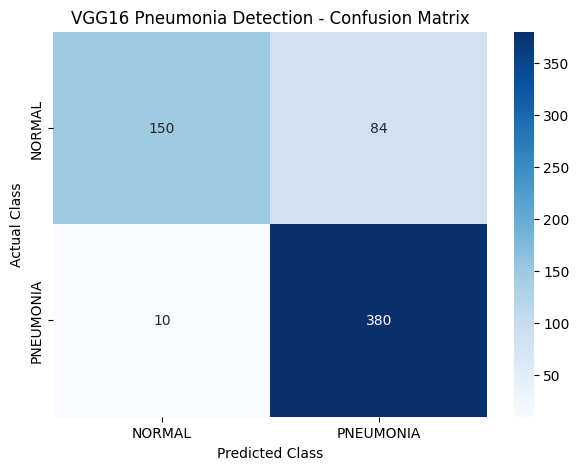

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("VGG16 Pneumonia Detection - Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

# Prediction probability
y_scores = predictions.ravel()

# ROC values
fpr, tpr, thresholds = roc_curve(true_classes, y_scores)

# AUC
roc_auc = auc(fpr, tpr)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9476550515012053


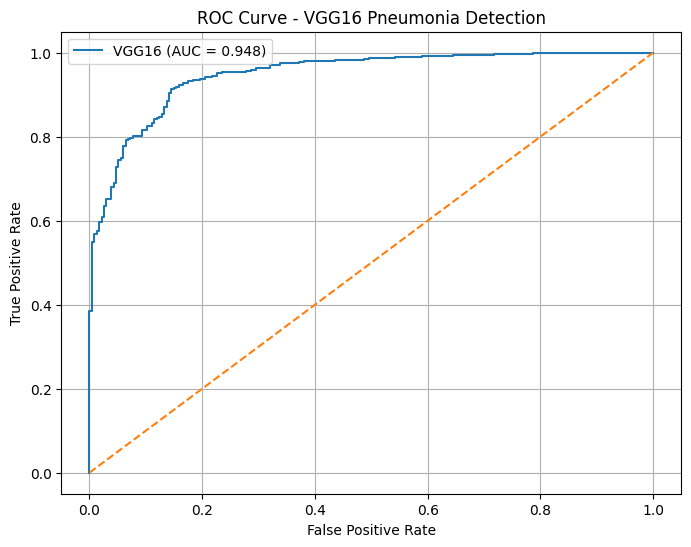

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"VGG16 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VGG16 Pneumonia Detection")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving image1.jpeg.jpg to image1.jpeg.jpg
Saving image2.jpeg.jpg to image2.jpeg.jpg
Saving image3.jpeg.jpg to image3.jpeg.jpg
Saving image4.jpeg.jpg to image4.jpeg.jpg
Saving image5.jpeg.jpg to image5.jpeg.jpg


In [ ]:
print("Uploaded images:")

for filename in uploaded.keys():
    print(filename)

Uploaded images:
image1.jpeg.jpg
image2.jpeg.jpg
image3.jpeg.jpg
image4.jpeg.jpg
image5.jpeg.jpg


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

results = []

for filename in uploaded.keys():

    # Load image
    img = image.load_img(
        filename,
        target_size=(224, 224)
    )

    # Convert to array
    img_array = image.img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # VGG16 preprocessing
    img_array = tf.keras.applications.vgg16.preprocess_input(img_array)

    # Prediction
    prediction = model.predict(img_array, verbose=0)[0][0]

    # Convert prediction
    if prediction >= 0.5:
        result = "PNEUMONIA"
        confidence = prediction * 100
    else:
        result = "NORMAL"
        confidence = (1 - prediction) * 100

    results.append({
        "Image": filename,
        "Prediction": result,
        "Confidence": confidence
    })

    print("--------------------------------")
    print("Image:", filename)
    print("Prediction:", result)
    print("Confidence:", round(confidence, 2), "%")

--------------------------------
Image: image1.jpeg.jpg
Prediction: PNEUMONIA
Confidence: 83.04 %
--------------------------------
Image: image2.jpeg.jpg
Prediction: PNEUMONIA
Confidence: 96.45 %
--------------------------------
Image: image3.jpeg.jpg
Prediction: PNEUMONIA
Confidence: 90.95 %
--------------------------------
Image: image4.jpeg.jpg
Prediction: PNEUMONIA
Confidence: 71.03 %
--------------------------------
Image: image5.jpeg.jpg
Prediction: NORMAL
Confidence: 55.33 %


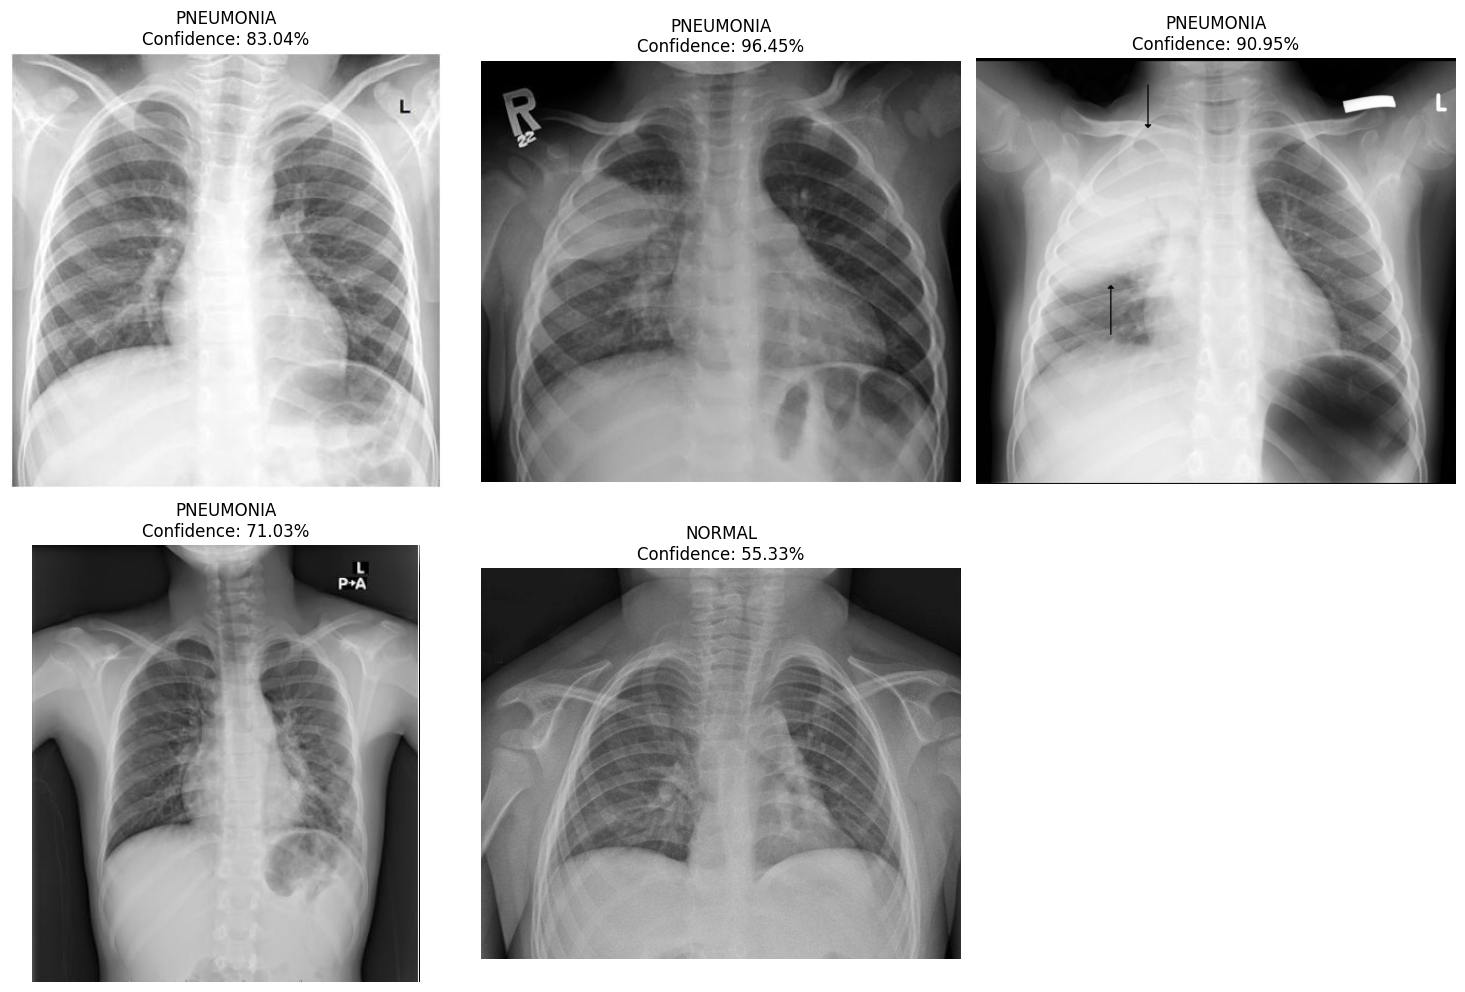

In [ ]:
plt.figure(figsize=(15, 10))

for i, filename in enumerate(uploaded.keys()):

    img = image.load_img(filename)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)

    result = results[i]["Prediction"]
    confidence = results[i]["Confidence"]

    plt.title(
        f"{result}\nConfidence: {confidence:.2f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig(
    "/content/pneumonia_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
import shutil

shutil.copy(
    "/content/pneumonia_predictions.png",
    "/content/drive/MyDrive/Pneumonia_VGG16/pneumonia_predictions.png"
)

print("Prediction image saved to Google Drive.")

Prediction image saved to Google Drive.


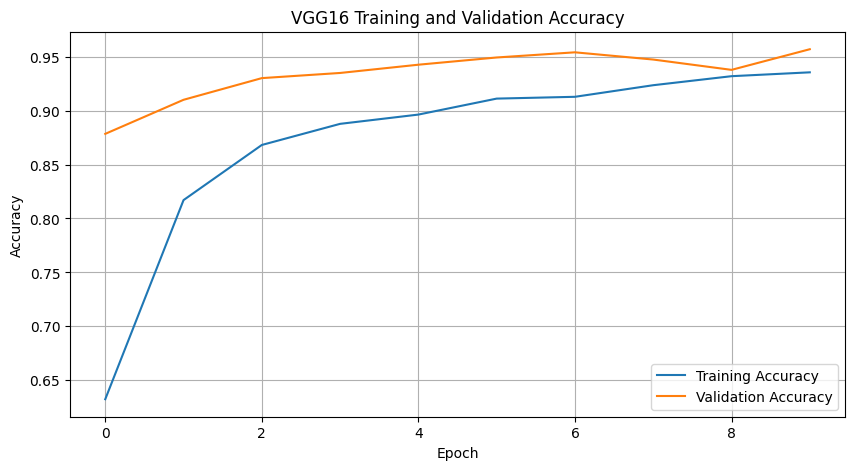

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("VGG16 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "/content/accuracy_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

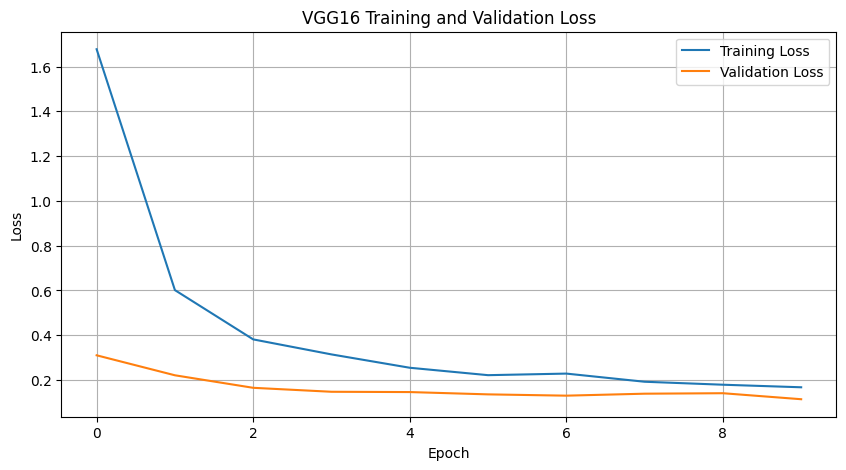

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("VGG16 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "/content/loss_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

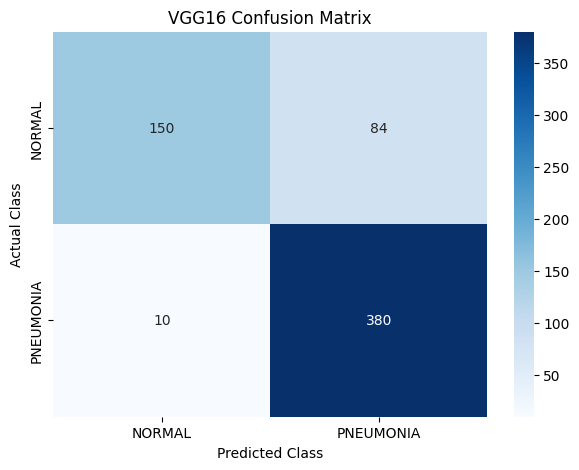

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("VGG16 Confusion Matrix")

plt.savefig(
    "/content/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

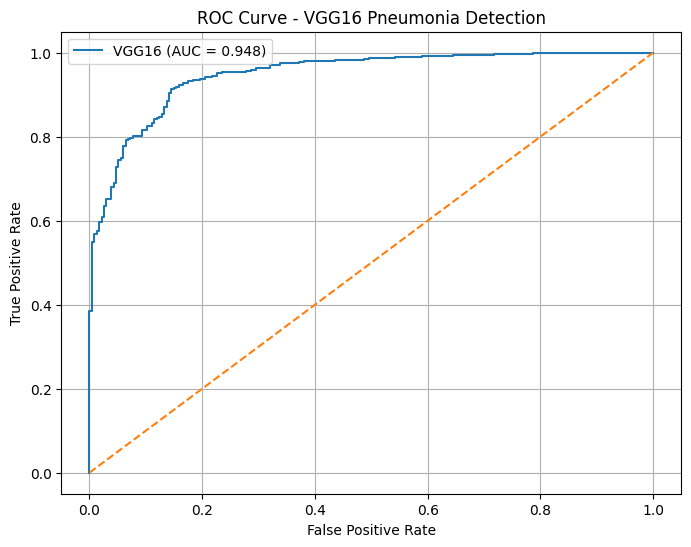

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"VGG16 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VGG16 Pneumonia Detection")

plt.legend()
plt.grid(True)

plt.savefig(
    "/content/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import shutil
import os

drive_folder = "/content/drive/MyDrive/Pneumonia_VGG16"

os.makedirs(drive_folder, exist_ok=True)

files_to_save = [
    "/content/accuracy_graph.png",
    "/content/loss_graph.png",
    "/content/confusion_matrix.png",
    "/content/roc_curve.png",
    "/content/pneumonia_predictions.png"
]

for file_path in files_to_save:
    if os.path.exists(file_path):
        shutil.copy(file_path, drive_folder)
        print("Saved:", os.path.basename(file_path))

Saved: accuracy_graph.png
Saved: loss_graph.png
Saved: confusion_matrix.png
Saved: roc_curve.png
Saved: pneumonia_predictions.png


In [ ]:
results_summary = {
    "Training Accuracy": history.history["accuracy"][-1] * 100,
    "Validation Accuracy": history.history["val_accuracy"][-1] * 100,
    "Test Accuracy": test_accuracy * 100,
    "Test Loss": test_loss,
    "ROC-AUC": roc_auc
}

for metric, value in results_summary.items():
    print(f"{metric}: {value:.2f}")

Training Accuracy: 93.55
Validation Accuracy: 95.69
Test Accuracy: 84.94
Test Loss: 0.36
ROC-AUC: 0.95
